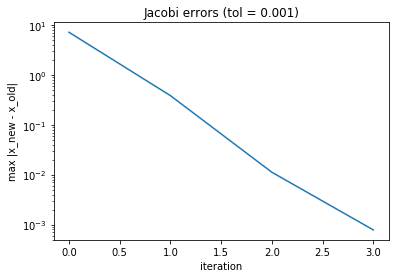

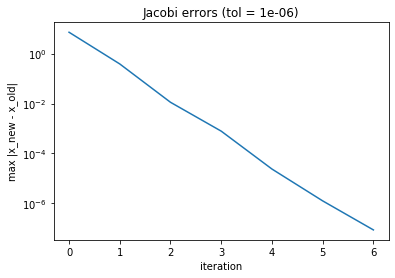

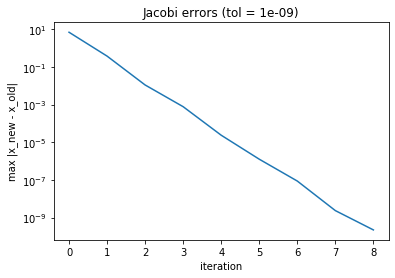

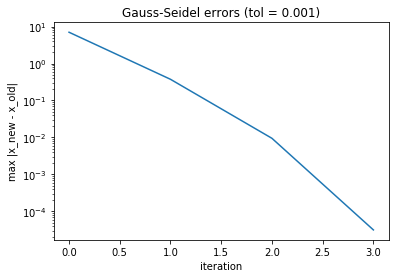

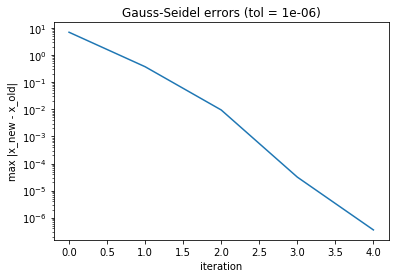

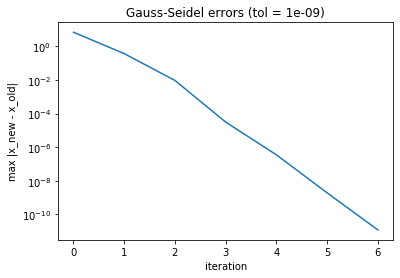

In [166]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([[3, -0.1, -0.2], [0.1, 7, -0.3], [0.3, -0.2, 10]])
b = np.array([7.85, -19.3, 71.4])

tol = np.array([10**-3, 10**-6, 10**-9])

def Jacobi(A, b, tol,errors):
    errors_by_tol = []
    for k in range (tol.shape[0]):

        isConverged = False
        x = np.zeros(A.shape[0])
        errors = []

        while(not isConverged):
            x_update = np.zeros(A.shape[0])

            ATermsArray = np.zeros(A.shape[0])

            for i in range(A.shape[0]):

                for j in range(A.shape[1]):
                    if (i == j):
                        continue

                    ATermsArray[i] += A[i][j]*(x[j])

                x_update[i] = (b[i] - ATermsArray[i])/A[i][i] 


            changes = np.zeros(A.shape[0])
            for i in range (A.shape[0]):
                changes[i] = x_update[i] - x[i]


            if np.max(np.abs(changes)) < tol[k]:
                isConverged = True  

            errors.append(np.max(np.abs(changes)))

            x = x_update

        errors_by_tol.append(errors)
            
    return errors_by_tol

        
def GaussSeidel(A,b,tol,errors):
    errors_by_tol = []
    for k in range (tol.shape[0]):
    
        isConverged = False
        x = np.zeros(A.shape[0])
        errors = []

        while(not isConverged):
            x_update = np.zeros(A.shape[0])

            ATermsArray = np.zeros(A.shape[0])

            for i in range(A.shape[0]):

                for j in range(A.shape[1]):
                    if (i == j):
                        continue
                    if (j < i):
                        ATermsArray[i] += A[i][j]*(x_update[j])
                    else:
                        ATermsArray[i] += A[i][j]*(x[j])

                x_update[i] = (b[i] - ATermsArray[i])/A[i][i] 


            changes = np.zeros(A.shape[0])
            for i in range (A.shape[0]):
                changes[i] = x_update[i] - x[i]


            if np.max(np.abs(changes)) < tol[k]:
                isConverged = True  
            
            
            errors.append(np.max(np.abs(changes)))
            
            x = x_update

        errors_by_tol.append(errors)
            
    return errors_by_tol


jacobi_errors = []
gs_errors = []

jacobi_errors = Jacobi(A,b,tol,jacobi_errors)
gs_errors = GaussSeidel(A,b,tol,gs_errors)

for k in range(tol.shape[0]):
    plt.figure()
    xVal = np.arange(0, len(jacobi_errors[k]))
    plt.plot(xVal, jacobi_errors[k])
    plt.yscale("log")
    plt.title("Jacobi errors (tol = " + str(tol[k]) + ")")
    plt.xlabel("iteration")
    plt.ylabel("max |x_new - x_old|")

for k in range(tol.shape[0]):
    plt.figure()
    xVal = np.arange(0, len(gs_errors[k]))
    plt.plot(xVal, gs_errors[k])
    plt.yscale("log")
    plt.title("Gauss-Seidel errors (tol = " + str(tol[k]) + ")")
    plt.xlabel("iteration")
    plt.ylabel("max |x_new - x_old|")



plt.show()

DISCUSSION QUESTION:
    
As you lower the tolerance it takes more iterations to get to get the estimation to converge for both Jacobi and Gauss-Siedel Methods